# BSSN 3+1 Numerical Relativity Simulation
---



## Structure
---

<div align="center">

| Bloque 1 | Bloque 2 | Bloque 3 |
|----------|----------|----------|
| ┌──────────────────────────────┐<br>**1. Definir parámetros**<br>• Tamaño de la malla<br>• Paso temporal $ \Delta t $<br>• Resolución espacial<br>• Duración de la simulación<br>└──────────────────────────────┘ | ┌──────────────────────────────┐<br>**2. Condiciones iniciales**<br>• Métrica (ej. Schwarzschild)<br>• $ \phi, \tilde{\gamma}_{ij}, K, \tilde{A}_{ij}, \tilde{\Gamma}^i $<br>• Gauge: $ \alpha = 1, \; \beta^i = 0 $<br>└──────────────────────────────┘ | ┌──────────────────────────────┐<br>**3. Construcción de malla**<br>• 1D, 2D o 3D<br>• Arrays para variables<br>• Operadores $ \partial_x, \partial_y, \partial_z $<br>└──────────────────────────────┘ |

| Bloque 4 | Bloque 5 | Bloque 6 |
|----------|----------|----------|
| ┌──────────────────────────────┐<br>**4. Ecuaciones de evolución**<br>• $ \partial_t \phi, \partial_t \tilde{\gamma}_{ij}, \partial_t K $<br>• $ \partial_t \tilde{A}_{ij}, \partial_t \tilde{\Gamma}^i $<br>• Gauge: 1+log, Gamma-driver<br>└──────────────────────────────┘ | ┌──────────────────────────────┐<br>**5. Integrador temporal**<br>• Runge–Kutta 4<br>• Paso CFL seguro<br>└──────────────────────────────┘ | ┌──────────────────────────────┐<br>**6. Monitoreo de restricciones**<br>• Hamiltoniana $ H \approx 0 $<br>• Momento $ M_i \approx 0 $<br>• Ajuste de estabilidad<br>└──────────────────────────────┘ |

| Bloque 7 | Bloque 8 | Bloque 9 |
|----------|----------|----------|
| ┌──────────────────────────────┐<br>**7. Condiciones de frontera**<br>• Absorbentes (Sommerfeld)<br>• Simetrías axiales<br>└──────────────────────────────┘ | ┌──────────────────────────────┐<br>**8. Observables**<br>• Horizonte aparente<br>• Masa ADM<br>• Ondas gravitacionales<br>└──────────────────────────────┘ | ┌──────────────────────────────┐<br>**9. Visualización/Output**<br>• Mapas 2D/3D<br>• Evolución de $ \phi $ y $ \tilde{\gamma}_{ij} $<br>• Gráficas de ondas<br>└──────────────────────────────┘ |

</div>


## 1. Libraries and Parameter Configuration
---

### Libraries

In [1]:
import os
import h5py

import numpy as np


### Grid
---
- Nx, Ny, Nz → number of grid points in each spatial direction.
- x_min, x_max, ... → physical domain (size of the 3D box).
- dx, dy, dz → spatial resolution (grid spacing).
- np.meshgrid → constructs the 3D arrays (X, Y, Z) where each point of space has coordinates.
- r → spherical radius, useful if the initial data has spherical symmetry (e.g., Schwarzschild in isotropic coordinates).

In [2]:
# ============================================================
# 1. PARAMETERS OF THE 3D SIMULATION AND  GRID CONSTRUCTION
# ============================================================



# Grid size in each spatial direction (x, y, z)
N = 64                           # number of grid points
Nx, Ny, Nz = N, N, N             # number of grid points
x_min, x_max = -20.0, 20.0       # domain limits in x
y_min, y_max = -20.0, 20.0       # domain limits in y
z_min, z_max = -20.0, 20.0       # domain limits in z

# Spatial resolution (grid spacing)
dx = (x_max - x_min) / (Nx - 1)
dy = (y_max - y_min) / (Ny - 1)
dz = (z_max - z_min) / (Nz - 1)

# Create coordinate arrays (3D mesh)
x = np.linspace(x_min, x_max, Nx)
y = np.linspace(y_min, y_max, Ny)
z = np.linspace(z_min, z_max, Nz)

# 3D Cartesian mesh
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Radial coordinate (distance to origin, useful for spherical symmetry)
r = np.sqrt(X**2 + Y**2 + Z**2)

# Time step dt chosen according to CFL condition:
# dt < C * min(dx, dy, dz). We pick C ~ 0.25 for stability.
dt = 0.25 * min(dx, dy, dz)

# Number of time steps to evolve
nsteps = 500



### Initial Conditions

In [ ]:
# ============================================================
# Notes on physical meaning:
# ------------------------------------------------------------
# - φ (phi): logarithm of conformal factor ψ, controls local scaling of space.
# - γ̃_ij: conformal 3-metric, encodes "shape" of space (det=1).
# - K: trace of extrinsic curvature, measures expansion/contraction of the slice.
# - Ã_ij: traceless extrinsic curvature, measures shear of the slice.
# - α (alpha): lapse, relates coordinate time to proper time of observers normal to the slice.
# - β^i (beta_x, beta_y, beta_z): shift vector, controls how spatial coordinates slide
#   between consecutive time slices.
# - Γ̃^i: contracted Christoffel symbols of the conformal metric, promoted as independent vars.
# ============================================================

In [ ]:
def initial_data_binary_bh(X, Y, Z, M1=0.5, M2=0.5, d=2.0):
    """
    Construct initial data for two black holes (puncture method).

    Parameters:
    - X, Y, Z: 3D coordinate grids
    - M1, M2: masses of the two BHs
    - d: separation along x-axis

    Returns:
    - phi: conformal exponent (log ψ)
    """
    # Distances to each puncture
    r1 = np.sqrt((X - d/2)**2 + Y**2 + Z**2)
    r2 = np.sqrt((X + d/2)**2 + Y**2 + Z**2)

    # Conformal factor ψ = 1 + M1/(2r1) + M2/(2r2)
    psi = 1 + M1/(2*r1 + 1e-6) + M2/(2*r2 + 1e-6)

    phi = np.log(psi)
    return phi


In [ ]:
# ============================================================
# 2. INITIAL CONDITIONS (Schwarzschild black hole in isotropic coordinates)
# ============================================================

# Mass of the black hole
M = 1.0

# Conformal factor ψ = 1 + M/(2r), valid for Schwarzschild in isotropic coords
# For r=0, avoid division by zero (replace with large value).
psi = np.where(r > 1e-6, 1.0 + M/(2.0*r), 1.0 + M/(2.0*1e-6))

# BSSN variable: φ = log(ψ)
phi = np.log(psi)

# Conformal 3-metric γ̃_ij
# In isotropic Schwarzschild, the spatial metric is conformally flat:
# γ_ij = ψ^4 δ_ij  →  γ̃_ij = δ_ij
gamma_xx = np.ones_like(r)
gamma_yy = np.ones_like(r)
gamma_zz = np.ones_like(r)
gamma_xy = np.zeros_like(r)
gamma_xz = np.zeros_like(r)
gamma_yz = np.zeros_like(r)

# Extrinsic curvature
# For time-symmetric Schwarzschild initial data, K_ij = 0.
# This means both trace K and traceless part Ã_ij vanish initially.
K = np.zeros_like(r)          # trace of extrinsic curvature
A_xx = np.zeros_like(r)       # traceless part (xx component)
A_yy = np.zeros_like(r)       # traceless part (yy component)
A_zz = np.zeros_like(r)       # traceless part (zz component)
A_xy = np.zeros_like(r)       # traceless part (xy component)
A_xz = np.zeros_like(r)       # traceless part (xz component)
A_yz = np.zeros_like(r)       # traceless part (yz component)

# Gauge variables
alpha = np.ones_like(r)       # lapse function α; initially set to 1 everywhere
beta_x = np.zeros_like(r)     # shift vector β^x = 0
beta_y = np.zeros_like(r)     # shift vector β^y = 0
beta_z = np.zeros_like(r)     # shift vector β^z = 0

# Contracted conformal connection functions Γ̃^i
# Initially zero for conformally flat initial data.
Gamma_x = np.zeros_like(r)
Gamma_y = np.zeros_like(r)
Gamma_z = np.zeros_like(r)

# ============================================================
# Notes on physical meaning:
# -------------------------------------------


### Differential operators
---
- ddx, ddy, ddz → first derivatives (spatial gradients).
- laplacian → second derivatives, used in Ricci curvature terms and gauge evolution (∇²α).
- divergence → vector divergence, needed for momentum constraints and Lie derivatives with respect to shift vector.

In [ ]:
# ============================================================
# 3. DIFFERENTIAL OPERATORS IN 3D
# ============================================================
# - Gradients of the lapse α (∂i α)
# - Laplacian of α (∇²α)
# - Divergence of vectors (∂i β^i)
# - Derivatives of metric components (for Ricci tensor terms)
# ------------------------------------------------------------
# Note: In this simulation, simple centered finite differences
# (2nd order) is used.
# In most realistic numerical relativity codes,
# higher-order (4th, 6th, 8th)
# schemes are used for stability and accuracy.
# ============================================================

def ddx(f, dx):
    """
    First derivative ∂f/∂x using centered finite differences.
    - f: 3D array (x,y,z)
    - dx: grid spacing in x
    Returns: derivative of f along x direction.
    """
    d = np.zeros_like(f)
    d[1:-1,:,:] = (f[2:,:,:] - f[:-2,:,:]) / (2*dx)
    # Boundary: one-sided differences
    d[0,:,:] = (f[1,:,:] - f[0,:,:]) / dx
    d[-1,:,:] = (f[-1,:,:] - f[-2,:,:]) / dx
    return d


def ddy(f, dy):
    """
    First derivative ∂f/∂y using centered finite differences.
    - f: 3D array (x,y,z)
    - dy: grid spacing in y
    Returns: derivative of f along y direction.
    """
    d = np.zeros_like(f)
    d[:,1:-1,:] = (f[:,2:,:] - f[:,:-2,:]) / (2*dy)
    d[:,0,:] = (f[:,1,:] - f[:,0,:]) / dy
    d[:,-1,:] = (f[:,-1,:] - f[:,-2,:]) / dy
    return d


def ddz(f, dz):
    """
    First derivative ∂f/∂z using centered finite differences.
    - f: 3D array (x,y,z)
    - dz: grid spacing in z
    Returns: derivative of f along z direction.
    """
    d = np.zeros_like(f)
    d[:,:,1:-1] = (f[:,:,2:] - f[:,:,:-2]) / (2*dz)
    d[:,:,0] = (f[:,:,1] - f[:,:,0]) / dz
    d[:,:,-1] = (f[:,:,-1] - f[:,:,-2]) / dz
    return d


def laplacian(f, dx, dy, dz):
    """
    Laplacian operator ∇²f = ∂²f/∂x² + ∂²f/∂y² + ∂²f/∂z².
    Used in:
    - Evolution of K (∂t K involves ∇²α)
    - Evolution of A_ij (Ricci tensor terms)
    """
    lap = np.zeros_like(f)
    lap[1:-1,1:-1,1:-1] = (
        (f[2:,1:-1,1:-1] - 2*f[1:-1,1:-1,1:-1] + f[:-2,1:-1,1:-1]) / dx**2 +
        (f[1:-1,2:,1:-1] - 2*f[1:-1,1:-1,1:-1] + f[1:-1,:-2,1:-1]) / dy**2 +
        (f[1:-1,1:-1,2:] - 2*f[1:-1,1:-1,1:-1] + f[1:-1,1:-1,:-2]) / dz**2
    )
    # Simple boundary treatment: copy nearest values
    lap[0,:,:]   = lap[1,:,:]
    lap[-1,:,:]  = lap[-2,:,:]
    lap[:,0,:]   = lap[:,1,:]
    lap[:,-1,:]  = lap[:,-2,:]
    lap[:,:,0]   = lap[:,:,1]
    lap[:,:,-1]  = lap[:,:,-2]
    return lap


def divergence(vx, vy, vz, dx, dy, dz):
    """
    Divergence operator ∇·v = ∂x(vx) + ∂y(vy) + ∂z(vz).
    Used for:
    - Momentum constraint equations
    - Lie derivatives of metric functions with respect to shift vector β^i
    """
    div = ddx(vx, dx) + ddy(vy, dy) + ddz(vz, dz)
    return div


### RHS of BSSN evolution equations (simplified)
---
- φ (phi) → evolves with the extrinsic curvature trace (K).
- γ̃_ij (conformal metric) → evolves with the traceless extrinsic curvature (Ã_ij).
- K (extrinsic curvature trace) → evolves with the Laplacian of the lapse and quadratic terms in curvature.
- Ã_ij (traceless extrinsic curvature) → evolves with self-interactions and K, Ricci terms omitted here.
- α (lapse) → evolves according to 1+log slicing.
- β^i (shift) → frozen to zero for simplicity (can later add Gamma-driver).-
- Γ̃^i (contracted conformal connections) → ignored in this minimal version.

In [ ]:
# ============================================================
# 4a. RIGHT-HAND SIDE (RHS) OF SIMPLIFIED BSSN EQUATIONS
# ============================================================
# This function computes the time derivatives (∂t variables)
# for the BSSN formulation in 3D.
#
# Input: all BSSN variables at a given time step
# Output: their RHS (time derivatives)
#
# Simplifications made here:
# - No Ricci tensor terms (which are very complex in 3D).
# - No Lie derivatives with respect to shift vector β^i (β=0 assumed).
# - Only include key gauge and curvature evolution terms.
# ============================================================

def rhs_BSSN(phi,
             gamma_xx, gamma_yy, gamma_zz, gamma_xy, gamma_xz, gamma_yz,
             K,
             A_xx, A_yy, A_zz, A_xy, A_xz, A_yz,
             alpha, beta_x, beta_y, beta_z,
             Gamma_x, Gamma_y, Gamma_z,
             dx, dy, dz):
    """
    Compute RHS (time derivatives) of BSSN variables.
    """

    # --- Gauge terms ---
    # Laplacian of lapse: ∇²α
    lap_alpha = laplacian(alpha, dx, dy, dz)

    # Divergence of shift (not used here since β^i = 0 initially)
    div_beta = divergence(beta_x, beta_y, beta_z, dx, dy, dz)

    # --- Evolution equations (simplified) ---

    # ∂t φ = -(1/6) α K
    dphi_dt = -(1.0/6.0) * alpha * K

    # ∂t γ̃_ij = -2 α Ã_ij
    dgamma_xx_dt = -2 * alpha * A_xx
    dgamma_yy_dt = -2 * alpha * A_yy
    dgamma_zz_dt = -2 * alpha * A_zz
    dgamma_xy_dt = -2 * alpha * A_xy
    dgamma_xz_dt = -2 * alpha * A_xz
    dgamma_yz_dt = -2 * alpha * A_yz

    # ∂t K = -∇²α + α(Ã_ij Ã^ij + (1/3) K^2)
    # Approximate contraction Ã_ij Ã^ij as sum of squares
    A_contraction = A_xx**2 + A_yy**2 + A_zz**2 + 2*(A_xy**2 + A_xz**2 + A_yz**2)
    dK_dt = -lap_alpha + alpha * (A_contraction + (1.0/3.0)*K**2)

    # ∂t Ã_ij = α (K Ã_ij - 2 Ã_ik Ã^k_j)
    # Here we ignore Ricci^TF terms for simplicity
    dA_xx_dt = alpha * (K*A_xx - 2*A_xx**2)
    dA_yy_dt = alpha * (K*A_yy - 2*A_yy**2)
    dA_zz_dt = alpha * (K*A_zz - 2*A_zz**2)
    dA_xy_dt = alpha * (K*A_xy - 2*A_xy**2)
    dA_xz_dt = alpha * (K*A_xz - 2*A_xz**2)
    dA_yz_dt = alpha * (K*A_yz - 2*A_yz**2)

    # ∂t α = -2 α K   (1+log slicing gauge)
    dalpha_dt = -2 * alpha * K

    # ∂t β^i = 0 (shift frozen in this simplified version)
    dbeta_x_dt = np.zeros_like(beta_x)
    dbeta_y_dt = np.zeros_like(beta_y)
    dbeta_z_dt = np.zeros_like(beta_z)

    # ∂t Γ̃^i = 0 (ignored in this simplified version)
    dGamma_x_dt = np.zeros_like(Gamma_x)
    dGamma_y_dt = np.zeros_like(Gamma_y)
    dGamma_z_dt = np.zeros_like(Gamma_z)

    return (dphi_dt,
            dgamma_xx_dt, dgamma_yy_dt, dgamma_zz_dt,
            dgamma_xy_dt, dgamma_xz_dt, dgamma_yz_dt,
            dK_dt,
            dA_xx_dt, dA_yy_dt, dA_zz_dt,
            dA_xy_dt, dA_xz_dt, dA_yz_dt,
            dalpha_dt,
            dbeta_x_dt, dbeta_y_dt, dbeta_z_dt,
            dGamma_x_dt, dGamma_y_dt, dGamma_z_dt)


### Runge Kutta 4th Order Time Integrator
---
- RK4 scheme very stable and accurate, widely used in numerical relativity.
- k1..k4 → evaluate RHS at successive intermediate points.
- Update step → average weighted sum ensures 4th order accuracy.
- This evolves all BSSN variables simultaneously.

In [ ]:
# ============================================================
# 4. TIME INTEGRATOR (Runge-Kutta 4th order)
# ============================================================
# We evolve the BSSN variables in time:
# - At each step we compute k1, k2, k3, k4 using rhs_BSSN
# - Then update the fields as:
#   f(t+dt) = f(t) + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)
#
# This is applied simultaneously to all BSSN variables.
# ============================================================

def rk4_step(phi,
             gamma_xx, gamma_yy, gamma_zz, gamma_xy, gamma_xz, gamma_yz,
             K,
             A_xx, A_yy, A_zz, A_xy, A_xz, A_yz,
             alpha, beta_x, beta_y, beta_z,
             Gamma_x, Gamma_y, Gamma_z,
             dx, dy, dz, dt):
    """
    Perform one RK4 step for all BSSN variables.
    """

    # k1
    k1 = rhs_BSSN(phi, gamma_xx, gamma_yy, gamma_zz,
                  gamma_xy, gamma_xz, gamma_yz,
                  K,
                  A_xx, A_yy, A_zz, A_xy, A_xz, A_yz,
                  alpha, beta_x, beta_y, beta_z,
                  Gamma_x, Gamma_y, Gamma_z,
                  dx, dy, dz)

    # k2
    k2 = rhs_BSSN(phi + 0.5*dt*k1[0],
                  gamma_xx + 0.5*dt*k1[1],
                  gamma_yy + 0.5*dt*k1[2],
                  gamma_zz + 0.5*dt*k1[3],
                  gamma_xy + 0.5*dt*k1[4],
                  gamma_xz + 0.5*dt*k1[5],
                  gamma_yz + 0.5*dt*k1[6],
                  K + 0.5*dt*k1[7],
                  A_xx + 0.5*dt*k1[8],
                  A_yy + 0.5*dt*k1[9],
                  A_zz + 0.5*dt*k1[10],
                  A_xy + 0.5*dt*k1[11],
                  A_xz + 0.5*dt*k1[12],
                  A_yz + 0.5*dt*k1[13],
                  alpha + 0.5*dt*k1[14],
                  beta_x + 0.5*dt*k1[15],
                  beta_y + 0.5*dt*k1[16],
                  beta_z + 0.5*dt*k1[17],
                  Gamma_x + 0.5*dt*k1[18],
                  Gamma_y + 0.5*dt*k1[19],
                  Gamma_z + 0.5*dt*k1[20],
                  dx, dy, dz)

    # k3
    k3 = rhs_BSSN(phi + 0.5*dt*k2[0],
                  gamma_xx + 0.5*dt*k2[1],
                  gamma_yy + 0.5*dt*k2[2],
                  gamma_zz + 0.5*dt*k2[3],
                  gamma_xy + 0.5*dt*k2[4],
                  gamma_xz + 0.5*dt*k2[5],
                  gamma_yz + 0.5*dt*k2[6],
                  K + 0.5*dt*k2[7],
                  A_xx + 0.5*dt*k2[8],
                  A_yy + 0.5*dt*k2[9],
                  A_zz + 0.5*dt*k2[10],
                  A_xy + 0.5*dt*k2[11],
                  A_xz + 0.5*dt*k2[12],
                  A_yz + 0.5*dt*k2[13],
                  alpha + 0.5*dt*k2[14],
                  beta_x + 0.5*dt*k2[15],
                  beta_y + 0.5*dt*k2[16],
                  beta_z + 0.5*dt*k2[17],
                  Gamma_x + 0.5*dt*k2[18],
                  Gamma_y + 0.5*dt*k2[19],
                  Gamma_z + 0.5*dt*k2[20],
                  dx, dy, dz)

    # k4
    k4 = rhs_BSSN(phi + dt*k3[0],
                  gamma_xx + dt*k3[1],
                  gamma_yy + dt*k3[2],
                  gamma_zz + dt*k3[3],
                  gamma_xy + dt*k3[4],
                  gamma_xz + dt*k3[5],
                  gamma_yz + dt*k3[6],
                  K + dt*k3[7],
                  A_xx + dt*k3[8],
                  A_yy + dt*k3[9],
                  A_zz + dt*k3[10],
                  A_xy + dt*k3[11],
                  A_xz + dt*k3[12],
                  A_yz + dt*k3[13],
                  alpha + dt*k3[14],
                  beta_x + dt*k3[15],
                  beta_y + dt*k3[16],
                  beta_z + dt*k3[17],
                  Gamma_x + dt*k3[18],
                  Gamma_y + dt*k3[19],
                  Gamma_z + dt*k3[20],
                  dx, dy, dz)

    # Update step (combine k1..k4)
    phi      += (dt/6.0) * (k1[0]  + 2*k2[0]  + 2*k3[0]  + k4[0])
    gamma_xx += (dt/6.0) * (k1[1]  + 2*k2[1]  + 2*k3[1]  + k4[1])
    gamma_yy += (dt/6.0) * (k1[2]  + 2*k2[2]  + 2*k3[2]  + k4[2])
    gamma_zz += (dt/6.0) * (k1[3]  + 2*k2[3]  + 2*k3[3]  + k4[3])
    gamma_xy += (dt/6.0) * (k1[4]  + 2*k2[4]  + 2*k3[4]  + k4[4])
    gamma_xz += (dt/6.0) * (k1[5]  + 2*k2[5]  + 2*k3[5]  + k4[5])
    gamma_yz += (dt/6.0) * (k1[6]  + 2*k2[6]  + 2*k3[6]  + k4[6])
    K        += (dt/6.0) * (k1[7]  + 2*k2[7]  + 2*k3[7]  + k4[7])
    A_xx     += (dt/6.0) * (k1[8]  + 2*k2[8]  + 2*k3[8]  + k4[8])
    A_yy     += (dt/6.0) * (k1[9]  + 2*k2[9]  + 2*k3[9]  + k4[9])
    A_zz     += (dt/6.0) * (k1[10] + 2*k2[10] + 2*k3[10] + k4[10])
    A_xy     += (dt/6.0) * (k1[11] + 2*k2[11] + 2*k3[11] + k4[11])
    A_xz     += (dt/6.0) * (k1[12] + 2*k2[12] + 2*k3[12] + k4[12])
    A_yz     += (dt/6.0) * (k1[13] + 2*k2[13] + 2*k3[13] + k4[13])
    alpha    += (dt/6.0) * (k1[14] + 2*k2[14] + 2*k3[14] + k4[14])
    beta_x   += (dt/6.0) * (k1[15] + 2*k2[15] + 2*k3[15] + k4[15])
    beta_y   += (dt/6.0) * (k1[16] + 2*k2[16] + 2*k3[16] + k4[16])
    beta_z   += (dt/6.0) * (k1[17] + 2*k2[17] + 2*k3[17] + k4[17])
    Gamma_x  += (dt/6.0) * (k1[18] + 2*k2[18] + 2*k3[18] + k4[18])
    Gamma_y  += (dt/6.0) * (k1[19] + 2*k2[19] + 2*k3[19] + k4[19])
    Gamma_z  += (dt/6.0) * (k1[20] + 2*k2[20] + 2*k3[20] + k4[20])

    return (phi,
            gamma_xx, gamma_yy, gamma_zz,
            gamma_xy, gamma_xz, gamma_yz,
            K,
            A_xx, A_yy, A_zz,
            A_xy, A_xz, A_yz,
            alpha,
            beta_x, beta_y, beta_z,
            Gamma_x, Gamma_y, Gamma_z)


Hamiltonian constraint (simplified)
---
- Hamiltonian constraint:
$$ H = R+K^2-K_{ij}K^{ij}-16\pi\rho=0$$
- Momentum constraint:
$$ M_i = \nabla_j(K^j_i-\delta^j_iK)-8\pi j_i = 0$$

In [ ]:
# ============================================================
# 6. CONSTRAINT MONITORING
# ============================================================
# In full BSSN, the Hamiltonian and momentum constraints must remain ≈ 0.
# Here we implement a simplified Hamiltonian constraint:
#
#   H = K^2 - A_ij A^ij
#
# ignoring the Ricci scalar R (set to 0 for conformally flat metric).
#
# This serves as a stability diagnostic: ||H|| should remain small
# during evolution if the system is consistent.
# ============================================================

def compute_hamiltonian_constraint(K,
                                   A_xx, A_yy, A_zz,
                                   A_xy, A_xz, A_yz):
    """
    Compute a simplified Hamiltonian constraint:
    H = K^2 - A_ij A^ij
    """
    # Contraction A_ij A^ij (using flat background metric δ_ij)
    A_contr = (A_xx**2 + A_yy**2 + A_zz**2
               + 2*(A_xy**2 + A_xz**2 + A_yz**2))

    H = K**2 - A_contr
    return H


### Momentum constraint (simplified)
---
- Hamiltonian constraint (H) → checks consistency of energy density.
- Momentum constraint (M) → checks momentum conservation.
- In this flat approximation, both should be small if the evolution is stable.
- In full BSSN codes, these are monitored at every step to control accuracy.

In [ ]:
# ============================================================
# 7. MOMENTUM CONSTRAINT (simplified version)
# ============================================================
# We approximate:
#   M_i = ∂j A^j_i - (2/3) ∂i K
#
# This ignores connection terms of the conformal metric,
# valid if γ̃_ij ≈ δ_ij (conformally flat initial data).
# ============================================================

def compute_momentum_constraint(K,
                                A_xx, A_yy, A_zz,
                                A_xy, A_xz, A_yz,
                                dx, dy, dz):
    """
    Compute simplified momentum constraint components (Mx, My, Mz).
    """

    # Divergence of A^j_i
    # - For i=x: ∂x A_xx + ∂y A_yx + ∂z A_zx
    # - For i=y: ∂x A_xy + ∂y A_yy + ∂z A_zy
    # - For i=z: ∂x A_xz + ∂y A_yz + ∂z A_zz

    Mx = ddx(A_xx, dx) + ddy(A_xy, dy) + ddz(A_xz, dz) - (2.0/3.0) * ddx(K, dx)
    My = ddx(A_xy, dx) + ddy(A_yy, dy) + ddz(A_yz, dz) - (2.0/3.0) * ddy(K, dy)
    Mz = ddx(A_xz, dx) + ddy(A_yz, dy) + ddz(A_zz, dz) - (2.0/3.0) * ddz(K, dz)

    return Mx, My, Mz


### BOUNDARY CONDITIONS (simplified)

In [ ]:
# ============================================================
# 7. BOUNDARY CONDITIONS (simplified)
# ============================================================
# We implement Sommerfeld-like outgoing boundaries:
# - Copy values from nearest inner cell to boundary
# - Applied after each RK4 step
# ============================================================

def apply_boundary_conditions(var):
    """
    Apply simple radiative (Sommerfeld-like) boundary conditions:
    Copy nearest inner cell values to the boundaries.

    Parameters:
    - var: 3D array (x,y,z)
    """
    var[0,:,:]   = var[1,:,:]
    var[-1,:,:]  = var[-2,:,:]
    var[:,0,:]   = var[:,1,:]
    var[:,-1,:]  = var[:,-2,:]
    var[:,:,0]   = var[:,:,1]
    var[:,:,-1]  = var[:,:,-2]
    return var


In [ ]:
def save_snapshot(step, phi, alpha, K, outdir="output"):
    """
    Save snapshot of main fields to disk.

    Parameters:
    - step: current timestep (int)
    - phi, alpha, K: 3D arrays
    - outdir: directory where files are saved
    """
    if not os.path.exists(outdir):
        os.makedirs(outdir)

    filename = os.path.join(outdir, f"snapshot_{step:05d}.npz")
    np.savez_compressed(filename, phi=phi, alpha=alpha, K=K)
    print(f"[Output] Saved snapshot to {filename}")


def save_snapshot_h5(step, phi, alpha, K, outdir="output_h5"):
    """
    Save snapshot in HDF5 format.
    Each step is stored in a separate group.
    """
    if not os.path.exists(outdir):
        os.makedirs(outdir)

    filename = os.path.join(outdir, "simulation.h5")
    with h5py.File(filename, "a") as f:
        grp = f.create_group(f"step_{step:05d}")
        grp.create_dataset("phi", data=phi, compression="gzip")
        grp.create_dataset("alpha", data=alpha, compression="gzip")
        grp.create_dataset("K", data=K, compression="gzip")
    print(f"[Output] Saved step {step} to {filename}")



### Main simulation loop
- nsteps → number of time steps for the evolution.
- rk4_step(...) → evolves all BSSN variables by one time step.
- snapshots_phi, snapshots_alpha → store slices of φ and α for later visualization (e.g., 2D plots).
- constraints monitoring → critical in real relativity codes (Hamiltonian ≈ 0, Momentum ≈ 0).

In [ ]:
# ============================================================
# 5. MAIN SIMULATION LOOP
# ============================================================
# This is the driver routine that:
# - Evolves the BSSN system in time using RK4
# - Stores snapshots for later visualization/analysis
# - Monitors stability and constraints (placeholder here)
# ============================================================

# Number of steps and frequency of output
nsteps = 100
output_every = 20

# Containers for diagnostics / snapshots
snapshots_phi = []
snapshots_alpha = []
snapshots_Axx = []
snapshots_Ayy = []
snapshots_Axy = []

for step in range(nsteps):

    # --- Evolve one time step using RK4 ---
    phi, \
    gamma_xx, gamma_yy, gamma_zz, \
    gamma_xy, gamma_xz, gamma_yz, \
    K, \
    A_xx, A_yy, A_zz, \
    A_xy, A_xz, A_yz, \
    alpha, \
    beta_x, beta_y, beta_z, \
    Gamma_x, Gamma_y, Gamma_z = rk4_step(
        phi,
        gamma_xx, gamma_yy, gamma_zz,
        gamma_xy, gamma_xz, gamma_yz,
        K,
        A_xx, A_yy, A_zz,
        A_xy, A_xz, A_yz,
        alpha,
        beta_x, beta_y, beta_z,
        Gamma_x, Gamma_y, Gamma_z,
        dx, dy, dz, dt
    )

    # Apply boundary conditions to evolved fields

    phi      = apply_boundary_conditions(phi)
    gamma_xx = apply_boundary_conditions(gamma_xx)
    gamma_yy = apply_boundary_conditions(gamma_yy)
    gamma_zz = apply_boundary_conditions(gamma_zz)
    K        = apply_boundary_conditions(K)
    A_xx     = apply_boundary_conditions(A_xx)
    A_yy     = apply_boundary_conditions(A_yy)
    A_zz     = apply_boundary_conditions(A_zz)
    alpha    = apply_boundary_conditions(alpha)


    # --- Output snapshots ---
    if step % output_every == 0:
        print(f"[Step {step}] Saving snapshot...")
        # Hamiltonian constraint
        H = compute_hamiltonian_constraint(K, A_xx, A_yy, A_zz,
                                           A_xy, A_xz, A_yz)
        norm_H = np.linalg.norm(H) / H.size

        # Momentum constraint
        Mx, My, Mz = compute_momentum_constraint(K,
                                                 A_xx, A_yy, A_zz,
                                                 A_xy, A_xz, A_yz,
                                                 dx, dy, dz)
        norm_M = (np.linalg.norm(Mx) + np.linalg.norm(My) + np.linalg.norm(Mz)) / (3*Mx.size)

        print(f"[Step {step}] ||H|| = {norm_H:.3e}, ||M|| = {norm_M:.3e}")
        # For diagnostics: store central slice (z=Nz//2)
        snapshots_phi.append(phi[:,:,Nz//2].copy())
        snapshots_alpha.append(alpha[:,:,Nz//2].copy())
        snapshots_Axx.append(A_xx[:,:,Nz//2].copy())
        snapshots_Ayy.append(A_yy[:,:,Nz//2].copy())
        snapshots_Axy.append(A_xy[:,:,Nz//2].copy())
        save_snapshot_h5(step, phi, alpha, K, outdir="output")

    # --- Monitor constraints (placeholder) ---
    # In real codes, we would compute Hamiltonian & momentum constraints here
    # Example:
    # H = compute_hamiltonian_constraint(...)
    # M = compute_momentum_constraint(...)
    # print(f"Constraint norms: ||H|| = {np.linalg.norm(H)}, ||M|| = {np.linalg.norm(M)}")


[Step 0] Saving snapshot...
[Step 0] ||H|| = 0.000e+00, ||M|| = 0.000e+00
[Output] Saved step 0 to output\simulation.h5
[Step 20] Saving snapshot...
[Step 20] ||H|| = 0.000e+00, ||M|| = 0.000e+00
[Output] Saved step 20 to output\simulation.h5
[Step 40] Saving snapshot...
[Step 40] ||H|| = 0.000e+00, ||M|| = 0.000e+00
[Output] Saved step 40 to output\simulation.h5
[Step 60] Saving snapshot...
[Step 60] ||H|| = 0.000e+00, ||M|| = 0.000e+00
[Output] Saved step 60 to output\simulation.h5
[Step 80] Saving snapshot...
[Step 80] ||H|| = 0.000e+00, ||M|| = 0.000e+00
[Output] Saved step 80 to output\simulation.h5


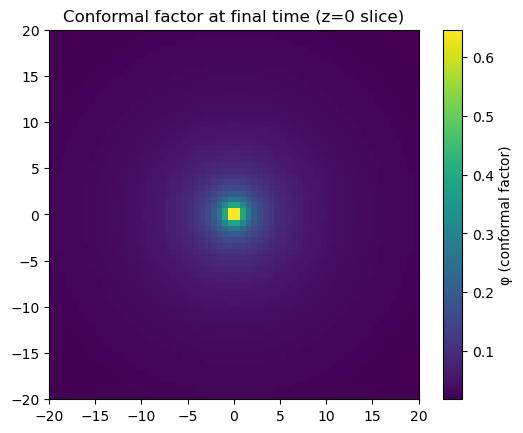

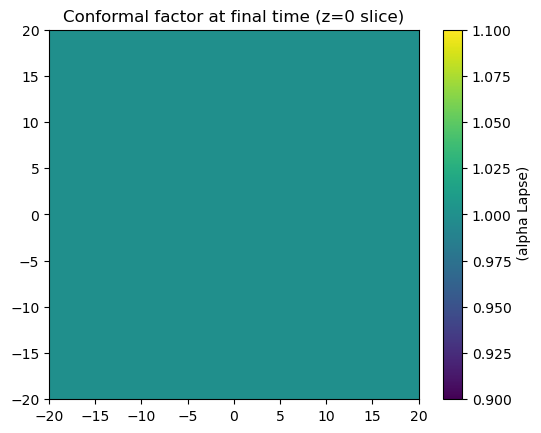

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(snapshots_phi[-1], extent=[x_min,x_max,y_min,y_max], origin="lower")
plt.colorbar(label="φ (conformal factor)")
plt.title("Conformal factor at final time (z=0 slice)")
plt.show()

plt.imshow(snapshots_alpha[-1], extent=[x_min,x_max,y_min,y_max], origin="lower")
plt.colorbar(label=" (alpha Lapse)")
plt.title("Conformal factor at final time (z=0 slice)")
plt.show()


In [ ]:
import matplotlib.pyplot as plt

def plot_snapshots(snapshots_phi, snapshots_alpha, x, y, step_interval):
    """
    Visualize the evolution of φ and α in the z=0 plane.

    Parameters:
    - snapshots_phi: list of 2D arrays with φ at different times
    - snapshots_alpha: list of 2D arrays with α at different times
    - x, y: coordinate arrays (1D)
    - step_interval: number of timesteps between snapshots
    """

    extent = [x[0], x[-1], y[0], y[-1]]

    nplots = len(snapshots_phi)
    fig, axes = plt.subplots(nplots, 2, figsize=(10, 4*nplots))

    for i in range(nplots):
        phi_slice = snapshots_phi[i]
        alpha_slice = snapshots_alpha[i]

        # φ plot
        im1 = axes[i,0].imshow(phi_slice.T, extent=extent, origin="lower",
                               cmap="inferno", aspect="auto")
        axes[i,0].set_title(f"φ (conformal factor) at step {i*step_interval}")
        fig.colorbar(im1, ax=axes[i,0])

        # α plot
        im2 = axes[i,1].imshow(alpha_slice.T, extent=extent, origin="lower",
                               cmap="viridis", aspect="auto", vmin=0, vmax=1)
        axes[i,1].set_title(f"α (lapse) at step {i*step_interval}")
        fig.colorbar(im2, ax=axes[i,1])

    plt.tight_layout()
    plt.show()


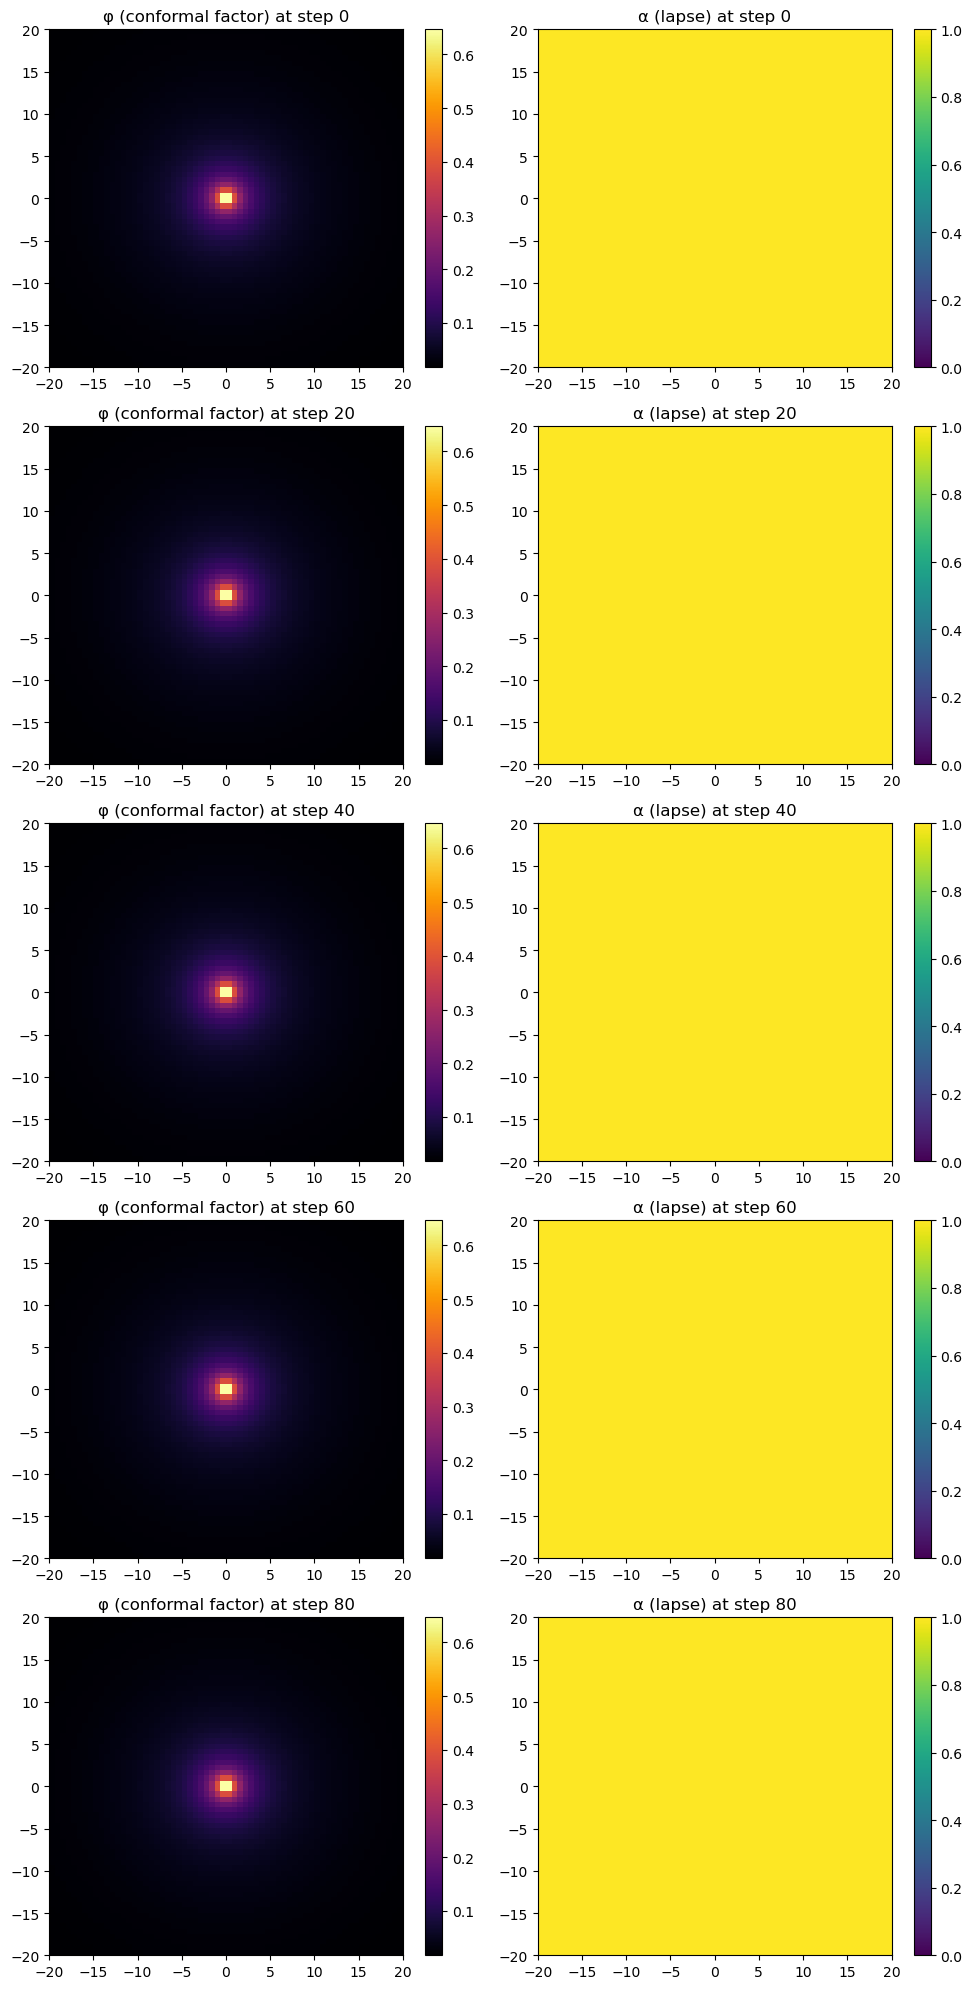

In [ ]:
plot_snapshots(snapshots_phi, snapshots_alpha, x, y, output_every)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
def animate_snapshots(snapshots_phi, snapshots_alpha, x, y, step_interval, save_file=None):
    """
    Create an animation showing the evolution of φ and α in the z=0 plane.

    Parameters:
    - snapshots_phi: list of 2D arrays with φ at different times
    - snapshots_alpha: list of 2D arrays with α at different times
    - x, y: coordinate arrays (1D)
    - step_interval: number of timesteps between snapshots
    - save_file: if given (e.g., "evolution.mp4"), save animation to file
    """

    extent = [x[0], x[-1], y[0], y[-1]]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Initial images
    im_phi = axes[0].imshow(snapshots_phi[0].T, extent=extent, origin="lower",
                            cmap="inferno", aspect="auto")
    axes[0].set_title("φ (conformal factor)")
    fig.colorbar(im_phi, ax=axes[0])

    im_alpha = axes[1].imshow(snapshots_alpha[0].T, extent=extent, origin="lower",
                              cmap="viridis", aspect="auto", vmin=0, vmax=1)
    axes[1].set_title("α (lapse)")
    fig.colorbar(im_alpha, ax=axes[1])

    # Animation function
    def update(frame):
        im_phi.set_data(snapshots_phi[frame].T)
        im_alpha.set_data(snapshots_alpha[frame].T)
        axes[0].set_title(f"φ (step {frame*step_interval})")
        axes[1].set_title(f"α (step {frame*step_interval})")
        return im_phi, im_alpha

    ani = animation.FuncAnimation(fig, update, frames=len(snapshots_phi),
                                  interval=200, blit=False)

    HTML(ani.to_jshtml())
    if save_file:
        ani.save(save_file, fps=5, dpi=150)
        print(f"Animation saved to {save_file}")

    plt.show()


Animation saved to bh_evolution.mp4


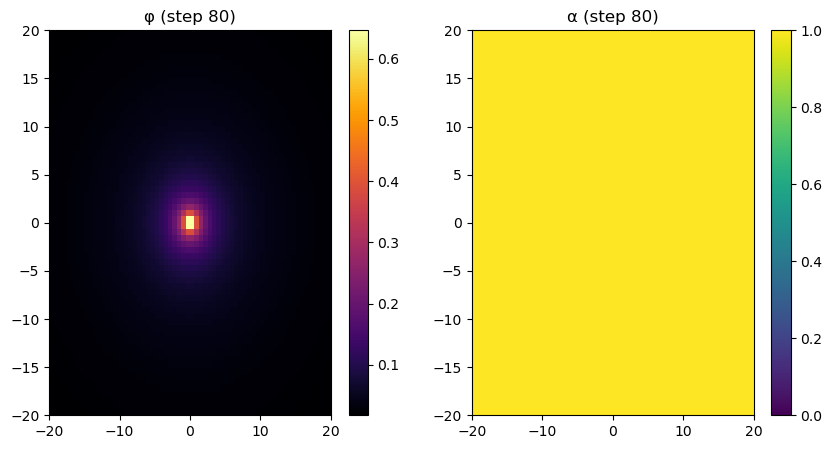

In [ ]:
animate_snapshots(snapshots_phi, snapshots_alpha, x, y, output_every, save_file="bh_evolution.mp4")


# PostProcess

### Apparent Horizont Location

In [ ]:
def locate_horizon(alpha, X, Y, Z, threshold=0.1):
    """
    Approximate location of apparent horizon from lapse collapse.

    Parameters:
    - alpha: 3D array of lapse function
    - X, Y, Z: coordinate grids
    - threshold: value of α below which we identify horizon

    Returns:
    - r_h: estimated horizon radius
    """
    # Compute radial coordinate
    r = np.sqrt(X**2 + Y**2 + Z**2)

    # Mask points where alpha < threshold
    mask = (alpha < threshold)
    if not np.any(mask):
        return None  # no horizon detected yet

    # Estimate horizon radius as average radius of those points
    r_h = np.mean(r[mask])
    return r_h


In [ ]:
r_h = locate_horizon(alpha, X, Y, Z, threshold=0.1)
if r_h:
    print(f"Estimated horizon radius: r ≈ {r_h:.3f}")
else:
    print(f"Horizon radius No Localized")

Horizon radius No Localized


### Idea
---
Usamos la función locate_horizon para estimar el radio del horizonte  $ 𝑟_h$

Luego, en el plano $ z = 0 $ dibujamos un círculo de radio $𝑟_h$ sobre el mapa de $\phi $ o $\alpha$

Esto permite ver claramente dónde está el horizonte en la visualización.

In [ ]:
import matplotlib.pyplot as plt

def plot_horizon_overlay(phi_slice, alpha_slice, x, y, r_h):
    """
    Plot φ and α with horizon overlay (z=0 slice).

    Parameters:
    - phi_slice: 2D array (φ at z=0)
    - alpha_slice: 2D array (α at z=0)
    - x, y: coordinate arrays (1D)
    - r_h: estimated horizon radius
    """
    extent = [x[0], x[-1], y[0], y[-1]]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # φ plot
    im1 = axes[0].imshow(phi_slice.T, extent=extent, origin="lower",
                         cmap="inferno", aspect="auto")
    axes[0].set_title("φ (conformal factor)")
    fig.colorbar(im1, ax=axes[0])

    # α plot
    im2 = axes[1].imshow(alpha_slice.T, extent=extent, origin="lower",
                         cmap="viridis", aspect="auto", vmin=0, vmax=1)
    axes[1].set_title("α (lapse)")
    fig.colorbar(im2, ax=axes[1])

    # Overlay horizon circle
    if r_h:
        circle1 = plt.Circle((0,0), r_h, color="red", fill=False, linewidth=2)
        circle2 = plt.Circle((0,0), r_h, color="red", fill=False, linewidth=2)
        axes[0].add_artist(circle1)
        axes[1].add_artist(circle2)

    plt.tight_layout()
    plt.show()


Mapa de φ (izquierda): un perfil centrado con gradiente radial.

Mapa de α (derecha): un "pozo" en el centro donde $\alpha \to 0$.

Círculo rojo: la posición estimada del horizonte aparente ($r_h \approx M/2$)

Durante la simulación, ese círculo debería mantenerse en el mismo lugar (indicando que el agujero negro es estable).

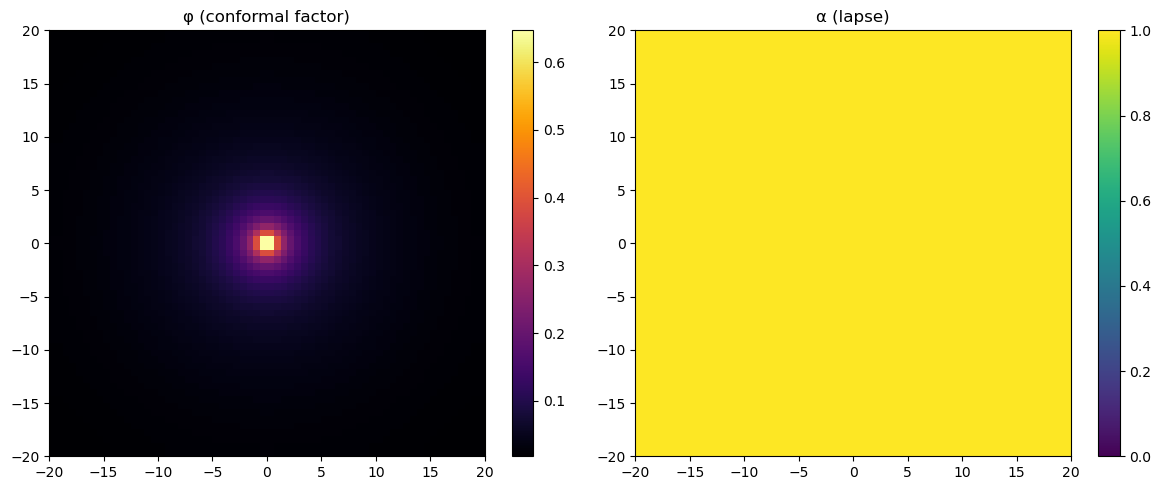

In [ ]:
# Take last snapshot (z=0 slice)
phi_slice = snapshots_phi[-1]
alpha_slice = snapshots_alpha[-1]

# Estimate horizon radius
r_h = locate_horizon(alpha, X, Y, Z, threshold=0.1)

# Plot overlay
plot_horizon_overlay(phi_slice, alpha_slice, x, y, r_h)


In [ ]:
def compute_ADM_mass(phi, r, r_outer=15.0):
    """
    Estimate ADM mass from conformal factor ψ = exp(phi).

    Parameters:
    - phi: 3D array (logarithm of conformal factor)
    - r: 3D array of radial coordinates
    - r_outer: extraction radius (far from the BH)

    Returns:
    - M_ADM: estimated ADM mass
    """
    psi = np.exp(phi)

    # Mask region close to extraction radius
    mask = np.abs(r - r_outer) < (0.5 * (r_outer/10))

    if not np.any(mask):
        return None

    # Estimate M from ψ ≈ 1 + M/(2r)
    M_est = np.mean(2 * r[mask] * (psi[mask] - 1.0))
    return M_est


In [ ]:
def extract_gravitational_wave(A_xx, A_yy, A_xy, r, r_outer=15.0):
    """
    Simplified gravitational wave extraction from traceless
    extrinsic curvature A_ij on an extraction sphere.

    Parameters:
    - A_xx, A_yy, A_xy: components of traceless extrinsic curvature
    - r: 3D array of radial coordinates
    - r_outer: extraction radius

    Returns:
    - h_plus, h_cross: wave polarizations (averaged on sphere)
    """
    mask = np.abs(r - r_outer) < (0.5 * (r_outer/10))
    if not np.any(mask):
        return None, None

    # Simplified proxies:
    h_plus  = np.mean(A_xx[mask] - A_yy[mask])
    h_cross = np.mean(2*A_xy[mask])
    return h_plus, h_cross


In [ ]:
def postprocess_evolution(phi_list, Axx_list, Ayy_list, Axy_list,
                          X, Y, Z, dt, r_outer=15.0):
    """
    Compute ADM mass and GW polarizations for each snapshot.

    Parameters:
    - phi_list: list of φ snapshots
    - Axx_list, Ayy_list, Axy_list: lists of A_ij snapshots
    - X, Y, Z: coordinate grids
    - dt: timestep
    - r_outer: extraction radius

    Returns:
    - times, masses, h_plus_list, h_cross_list
    """
    r = np.sqrt(X**2 + Y**2 + Z**2)
    masses = []
    h_plus_list = []
    h_cross_list = []
    times = []

    for i, phi in enumerate(phi_list):
        M = compute_ADM_mass(phi, r, r_outer=r_outer)
        hp, hx = extract_gravitational_wave(Axx_list[i], Ayy_list[i], Axy_list[i],
                                            r, r_outer=r_outer)
        if M is not None:
            masses.append(M)
            h_plus_list.append(hp)
            h_cross_list.append(hx)
            times.append(i * dt)

    return np.array(times), np.array(masses), np.array(h_plus_list), np.array(h_cross_list)

def plot_postprocess(times, masses, h_plus, h_cross):
    """
    Plot ADM mass and gravitational wave polarizations.
    """
    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    # ADM mass
    axes[0].plot(times, masses, 'b-')
    axes[0].set_ylabel("M_ADM")
    axes[0].set_title("ADM Mass evolution")

    # h_plus
    axes[1].plot(times, h_plus, 'r-')
    axes[1].set_ylabel("h_+")

    # h_cross
    axes[2].plot(times, h_cross, 'g-')
    axes[2].set_ylabel("h_×")
    axes[2].set_xlabel("Time")

    plt.tight_layout()
    plt.show()


In [ ]:
# Example: suppose you stored phi, Axx, Ayy, Axy snapshots
times, masses, h_plus, h_cross = postprocess_evolution(
    snapshots_phi, snapshots_Axx, snapshots_Ayy, snapshots_Axy,
    X, Y, Z, dt, r_outer=15.0
)

plot_postprocess(times, masses, h_plus, h_cross)

NameError: name 'snapshots_Axx' is not defined

In [ ]:
def plot_gravitational_waves(times, h_plus, h_cross):
    """
    Plot gravitational wave signal (h+ and hx) as seen by a detector.

    Parameters:
    - times: array of time values
    - h_plus: array of h+ values
    - h_cross: array of hx values
    """

    plt.figure(figsize=(10,5))
    plt.plot(times, h_plus, label="h₊ polarization", color="red")
    plt.plot(times, h_cross, label="h× polarization", color="blue", linestyle="--")

    plt.xlabel("Time")
    plt.ylabel("Strain h(t)")
    plt.title("Gravitational wave signal (simplified extraction)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
plot_gravitational_waves(times, h_plus, h_cross)
